# Wazuh ML modeling

Notebook: preprocessing, feature engineering, model training, evaluation, and export.


In [25]:
from pathlib import Path
import json
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
import sklearn
import joblib

try:
    from imblearn.over_sampling import RandomOverSampler
    from imblearn.pipeline import Pipeline as ImbPipeline
except Exception:
    RandomOverSampler = None
    ImbPipeline = None


In [26]:
SEED = 42
np.random.seed(SEED)

BASE_DIR = Path("..").resolve()
DATA_PATH = BASE_DIR / "data" / "labeled_logs.csv"
MODELS_DIR = BASE_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

GREEN = "#076d27"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Missing labeled dataset: {DATA_PATH}")

df = pd.read_csv(DATA_PATH, low_memory=False)
print("Shape:", df.shape)
df.head()


Shape: (2563, 12)


,@timestamp,agent.name,agent.id,rule.id,rule.description,rule.level,rule.mitre.id,location,data.win.eventdata.commandLine,raw,severity,attack_type
0,2025-12-27T14:10:22.179Z,wazuh-vm,0,510,Host-based anomaly detection event (rootcheck).,7,NaN,rootcheck,NaN,"{'agent': {'name': 'wazuh-vm', 'id': '000'}, '...",high,T1136
1,2025-12-27T14:10:22.211Z,wazuh-vm,0,510,Host-based anomaly detection event (rootcheck).,7,NaN,rootcheck,NaN,"{'agent': {'name': 'wazuh-vm', 'id': '000'}, '...",high,T1136
2,2025-12-27T14:10:29.858Z,wazuh-vm,0,502,Wazuh server started.,3,NaN,wazuh-monitord,NaN,"{'agent': {'name': 'wazuh-vm', 'id': '000'}, '...",low,T1562.001
3,2025-12-27T14:10:31.706Z,wazuh-vm,0,2901,New dpkg (Debian Package) requested to install.,3,NaN,/var/log/dpkg.log,NaN,"{'agent': {'name': 'wazuh-vm', 'id': '000'}, '...",low,T1136
4,2025-12-27T14:10:35.717Z,wazuh-vm,0,2904,Dpkg (Debian Package) half configured.,7,NaN,/var/log/dpkg.log,NaN,"{'agent': {'name': 'wazuh-vm', 'id': '000'}, '...",high,T1136


In [27]:
print(df.dtypes)
missing_rate = df.isna().mean().sort_values(ascending=False)
missing_rate.head(10)


@timestamp                        object
agent.name                        object
agent.id                           int64
rule.id                            int64
rule.description                  object
rule.level                         int64
rule.mitre.id                     object
location                          object
data.win.eventdata.commandLine    object
raw                               object
severity                          object
attack_type                       object
dtype: object


data.win.eventdata.commandLine    0.748732
rule.mitre.id                     0.507998
@timestamp                        0.000000
agent.name                        0.000000
rule.id                           0.000000
agent.id                          0.000000
rule.level                        0.000000
rule.description                  0.000000
location                          0.000000
raw                               0.000000
dtype: float64

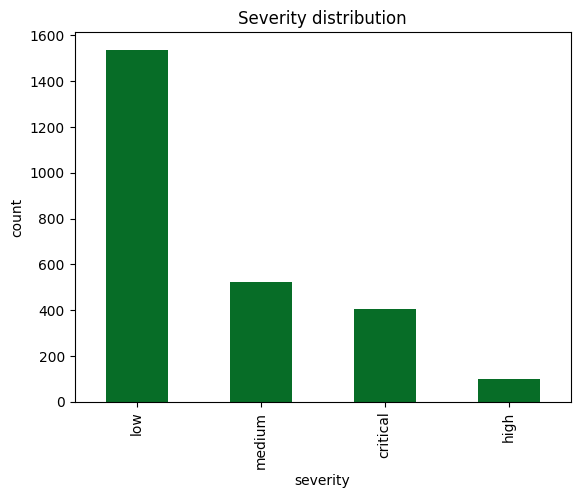

In [28]:
severity_counts = df.get("severity", pd.Series(dtype=str)).value_counts()
ax = severity_counts.plot(kind="bar", color=GREEN, title="Severity distribution")
ax.set_xlabel("severity")
ax.set_ylabel("count")
plt.show()


In [29]:
TEXT_COLUMNS = [
    "rule.description",
    "raw",
    "data.win.eventdata.commandLine",
    "location",
    "rule.id",
    "agent.name",
    "agent.id",
]

def add_features(frame: pd.DataFrame) -> pd.DataFrame:
    df_local = frame.copy()

    if "@timestamp" in df_local.columns:
        ts = pd.to_datetime(df_local["@timestamp"], errors="coerce")
        df_local["hour"] = ts.dt.hour
        df_local["dayofweek"] = ts.dt.dayofweek
        df_local["month"] = ts.dt.month
    else:
        df_local["hour"] = np.nan
        df_local["dayofweek"] = np.nan
        df_local["month"] = np.nan

    available = [col for col in TEXT_COLUMNS if col in df_local.columns]
    if available:
        df_local["text_global"] = (
            df_local[available]
            .fillna("")
            .astype(str)
            .agg(" ".join, axis=1)
            .str.replace(r"\s+", " ", regex=True)
            .str.strip()
        )
    else:
        df_local["text_global"] = ""
    return df_local

df_feat = add_features(df)
df_feat[["text_global", "hour", "dayofweek", "month"]].head()


,text_global,hour,dayofweek,month
0,Host-based anomaly detection event (rootcheck)...,14,5,12
1,Host-based anomaly detection event (rootcheck)...,14,5,12
2,Wazuh server started. {'agent': {'name': 'wazu...,14,5,12
3,New dpkg (Debian Package) requested to install...,14,5,12
4,Dpkg (Debian Package) half configured. {'agent...,14,5,12


In [30]:
feature_cols = ["text_global", "hour", "dayofweek", "month"]
if "rule.level" in df_feat.columns:
    feature_cols.append("rule.level")

X = df_feat[feature_cols]
y_severity = df_feat.get("severity", pd.Series(["low"] * len(df_feat))).fillna("low")
y_attack = df_feat.get("attack_type", pd.Series(["UNKNOWN"] * len(df_feat))).fillna("UNKNOWN")

print("Features:", feature_cols)
print("Severity classes:", sorted(y_severity.unique()))
print("Attack classes:", sorted(y_attack.unique())[:10])


Features: ['text_global', 'hour', 'dayofweek', 'month', 'rule.level']
Severity classes: ['critical', 'high', 'low', 'medium']
Attack classes: ['T1021.006', 'T1027;T1112', 'T1053.005', 'T1055', 'T1059.001', 'T1059.003', 'T1059.003;T1574.001', 'T1059;T1105', 'T1078', 'T1078;T1531']


In [31]:
numeric_features = [col for col in ["hour", "dayofweek", "month", "rule.level"] if col in X.columns]
text_feature = "text_global"

text_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="")),
    ("to_text", FunctionTransformer(lambda x: x.squeeze(), validate=False)),
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=5000)),
])

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

transformers = [("text", text_pipeline, [text_feature])]
if numeric_features:
    transformers.append(("num", numeric_pipeline, numeric_features))

preprocess = ColumnTransformer(transformers)

def make_pipeline(model, sampler=None, dense_after=False):
    steps = [("preprocess", preprocess)]
    if sampler is not None and ImbPipeline is not None:
        steps.append(("sampler", sampler))
    if dense_after:
        steps.append(("to_dense", FunctionTransformer(
            lambda x: x.toarray() if hasattr(x, "toarray") else x,
            validate=False,
        )))
    steps.append(("clf", model))
    pipeline_cls = ImbPipeline if (sampler is not None and ImbPipeline is not None) else Pipeline
    return pipeline_cls(steps)


In [32]:
def run_search(X_train, y_train, spec, sampler=None):
    pipe = make_pipeline(spec["model"], sampler=sampler, dense_after=spec.get("dense", False))
    search = RandomizedSearchCV(
        pipe,
        spec["params"],
        n_iter=spec.get("n_iter", 10),
        scoring={
            "f1_macro": "f1_macro",
            "bal_acc": "balanced_accuracy",
        },
        refit="f1_macro",
        cv=3,
        random_state=SEED,
        n_jobs=-1,
        verbose=0,
    )
    search.fit(X_train, y_train)
    return search

def evaluate_model(model, X_test, y_test, label):
    preds = model.predict(X_test)
    print(f"\n[{label}] Balanced acc:", balanced_accuracy_score(y_test, preds))
    print(f"[{label}] F1 macro:", f1_score(y_test, preds, average="macro"))
    print(classification_report(y_test, preds))
    print("Confusion matrix:\n", confusion_matrix(y_test, preds))
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.imshow(confusion_matrix(y_test, preds), cmap="Blues")
    ax.set_title(f"{label} confusion matrix")
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    plt.show()
    return preds

def _unwrap_estimator(model):
    if hasattr(model, "best_estimator_"):
        return model.best_estimator_
    return model

def top_k_accuracy(model, X_test, y_test, k=3):
    estimator = _unwrap_estimator(model)
    if hasattr(estimator, "predict_proba"):
        scores = estimator.predict_proba(X_test)
        classes = estimator.named_steps["clf"].classes_
    elif hasattr(estimator, "decision_function"):
        scores = estimator.decision_function(X_test)
        classes = estimator.named_steps["clf"].classes_
    else:
        return None

    scores = np.asarray(scores)
    top_idx = np.argsort(scores, axis=1)[:, -k:]
    top_labels = classes[top_idx]
    matches = [y in top_labels[i] for i, y in enumerate(y_test)]
    return float(np.mean(matches))


In [33]:
def summarize_searches(searches, label):
    rows = []
    for name, search in searches.items():
        rows.append({
            "model": name,
            "best_f1_macro": float(search.best_score_) if hasattr(search, "best_score_") else None,
            "best_params": search.best_params_,
        })
    df = pd.DataFrame(rows).sort_values("best_f1_macro", ascending=False)
    print(f"\n{label} - best params")
    print(df.to_string(index=False))
    return df


def plot_search_summary(df, title):
    if df is None or df.empty:
        return
    ax = df.plot(kind="bar", x="model", y="best_f1_macro", legend=False, color=GREEN, title=title)
    ax.set_ylabel("best f1_macro (cv)")
    ax.set_xlabel("model")
    plt.show()


In [34]:
def plot_cv_results(search, title):
    if not hasattr(search, 'cv_results_'):
        return
    df = pd.DataFrame(search.cv_results_)
    score_col = 'mean_test_f1_macro' if 'mean_test_f1_macro' in df.columns else 'mean_test_score'
    param_cols = [c for c in df.columns if c.startswith('param_')]
    if not param_cols or score_col not in df.columns:
        return

    plt.figure(figsize=(7, 4))
    if len(param_cols) == 1:
        x = df[param_cols[0]].astype(str)
        y = df[score_col]
        plt.plot(x, y, marker='o')
        plt.title(title)
        plt.xlabel(param_cols[0].replace('param_', ''))
        plt.ylabel(score_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        return

    if len(param_cols) == 2:
        pivot = df.pivot_table(values=score_col, index=param_cols[0], columns=param_cols[1])
        plt.imshow(pivot.values, aspect='auto', cmap='viridis')
        plt.title(title)
        plt.xlabel(param_cols[1].replace('param_', ''))
        plt.ylabel(param_cols[0].replace('param_', ''))
        plt.colorbar(label=score_col)
        plt.xticks(ticks=range(len(pivot.columns)), labels=[str(x) for x in pivot.columns], rotation=45, ha='right')
        plt.yticks(ticks=range(len(pivot.index)), labels=[str(x) for x in pivot.index])
        plt.tight_layout()
        plt.show()
        return

    top = df.sort_values(score_col, ascending=False).head(15)
    plt.bar(range(len(top)), top[score_col])
    plt.title(title + ' (top 15)')
    plt.xlabel('trial')
    plt.ylabel(score_col)
    plt.tight_layout()
    plt.show()


In [35]:
sampler = None
if RandomOverSampler is not None:
    sampler = RandomOverSampler(random_state=SEED)


## Severity modeling

In [36]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X,
    y_severity,
    test_size=0.2,
    random_state=SEED,
    stratify=y_severity,
)


c:\Users\Kebiyer\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\Kebiyer\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(



[severity/logreg] Balanced acc: 1.0
[severity/logreg] F1 macro: 1.0
              precision    recall  f1-score   support

    critical       1.00      1.00      1.00        81
        high       1.00      1.00      1.00        19
         low       1.00      1.00      1.00       308
      medium       1.00      1.00      1.00       105

    accuracy                           1.00       513
   macro avg       1.00      1.00      1.00       513
weighted avg       1.00      1.00      1.00       513

Confusion matrix:
 [[ 81   0   0   0]
 [  0  19   0   0]
 [  0   0 308   0]
 [  0   0   0 105]]


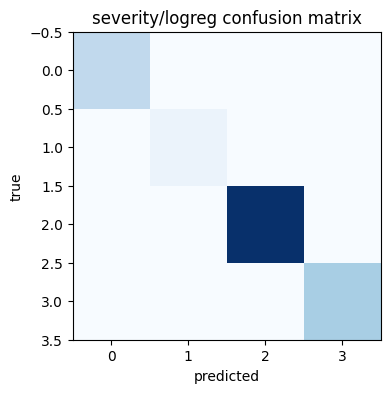

array(['low', 'low', 'low', 'low', 'medium', 'low', 'low', 'medium',
       'critical', 'low', 'low', 'low', 'low', 'medium', 'critical',
       'low', 'medium', 'medium', 'low', 'low', 'critical', 'low', 'low',
       'critical', 'low', 'low', 'low', 'medium', 'medium', 'critical',
       'low', 'low', 'medium', 'medium', 'low', 'low', 'low', 'low',
       'critical', 'low', 'low', 'critical', 'critical', 'low', 'low',
       'critical', 'critical', 'low', 'low', 'low', 'high', 'medium',
       'low', 'medium', 'low', 'low', 'high', 'low', 'low', 'low',
       'medium', 'critical', 'high', 'low', 'critical', 'low', 'medium',
       'low', 'low', 'low', 'low', 'low', 'low', 'low', 'low', 'low',
       'low', 'medium', 'low', 'medium', 'low', 'low', 'low', 'low',
       'critical', 'low', 'medium', 'low', 'low', 'low', 'medium', 'low',
       'low', 'medium', 'medium', 'medium', 'low', 'low', 'low', 'medium',
       'low', 'low', 'critical', 'low', 'medium', 'low', 'low', 'low',
       

In [37]:
# Severity: Logistic Regression
severity_logreg_spec = {
    "model": LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear"),
    "params": {"clf__C": [0.1, 1, 3, 10]},
}
severity_logreg = run_search(X_train_s, y_train_s, severity_logreg_spec, sampler=sampler)
evaluate_model(severity_logreg, X_test_s, y_test_s, "severity/logreg")


c:\Users\Kebiyer\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\Kebiyer\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



[severity/linear_svc] Balanced acc: 1.0
[severity/linear_svc] F1 macro: 1.0
              precision    recall  f1-score   support

    critical       1.00      1.00      1.00        81
        high       1.00      1.00      1.00        19
         low       1.00      1.00      1.00       308
      medium       1.00      1.00      1.00       105

    accuracy                           1.00       513
   macro avg       1.00      1.00      1.00       513
weighted avg       1.00      1.00      1.00       513

Confusion matrix:
 [[ 81   0   0   0]
 [  0  19   0   0]
 [  0   0 308   0]
 [  0   0   0 105]]


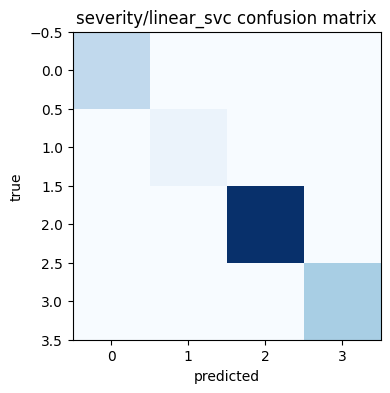

array(['low', 'low', 'low', 'low', 'medium', 'low', 'low', 'medium',
       'critical', 'low', 'low', 'low', 'low', 'medium', 'critical',
       'low', 'medium', 'medium', 'low', 'low', 'critical', 'low', 'low',
       'critical', 'low', 'low', 'low', 'medium', 'medium', 'critical',
       'low', 'low', 'medium', 'medium', 'low', 'low', 'low', 'low',
       'critical', 'low', 'low', 'critical', 'critical', 'low', 'low',
       'critical', 'critical', 'low', 'low', 'low', 'high', 'medium',
       'low', 'medium', 'low', 'low', 'high', 'low', 'low', 'low',
       'medium', 'critical', 'high', 'low', 'critical', 'low', 'medium',
       'low', 'low', 'low', 'low', 'low', 'low', 'low', 'low', 'low',
       'low', 'medium', 'low', 'medium', 'low', 'low', 'low', 'low',
       'critical', 'low', 'medium', 'low', 'low', 'low', 'medium', 'low',
       'low', 'medium', 'medium', 'medium', 'low', 'low', 'low', 'medium',
       'low', 'low', 'critical', 'low', 'medium', 'low', 'low', 'low',
       

In [38]:
# Severity: Linear SVC
severity_linear_svc_spec = {
    "model": LinearSVC(class_weight="balanced"),
    "params": {"clf__C": [0.1, 1, 3, 10]},
}
severity_linear_svc = run_search(X_train_s, y_train_s, severity_linear_svc_spec, sampler=sampler)
evaluate_model(severity_linear_svc, X_test_s, y_test_s, "severity/linear_svc")


In [39]:
severity_searches = {
    "logreg": severity_logreg,
    "linear_svc": severity_linear_svc,
}

best_severity = max(severity_searches.values(), key=lambda item: item.best_score_)
print("Best severity model:", best_severity.best_estimator_)


Best severity model: Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('text',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='',
                                                                                 strategy='constant')),
                                                                  ('to_text',
                                                                   FunctionTransformer(func=<function <lambda> at 0x0000023728F904A0>)),
                                                                  ('tfidf',
                                                                   TfidfVectorizer(max_features=5000,
                                                                                   ngram_range=(1,
                                                                                                2)))]),
                


Severity - best params
     model  best_f1_macro   best_params
linear_svc       0.999600 {'clf__C': 1}
    logreg       0.998129 {'clf__C': 1}


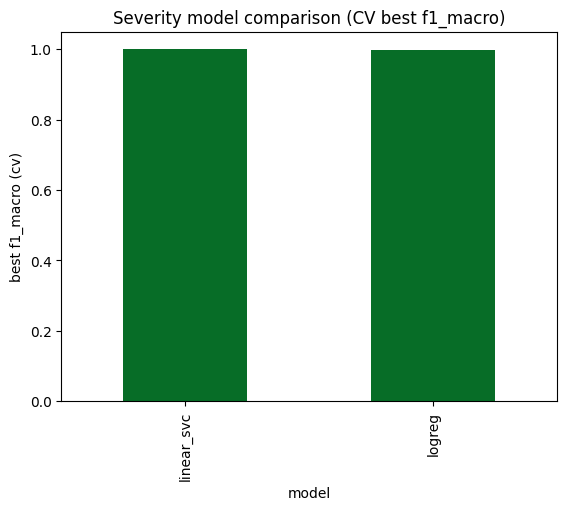

In [40]:
severity_summary = summarize_searches(severity_searches, "Severity")
plot_search_summary(severity_summary, "Severity model comparison (CV best f1_macro)")


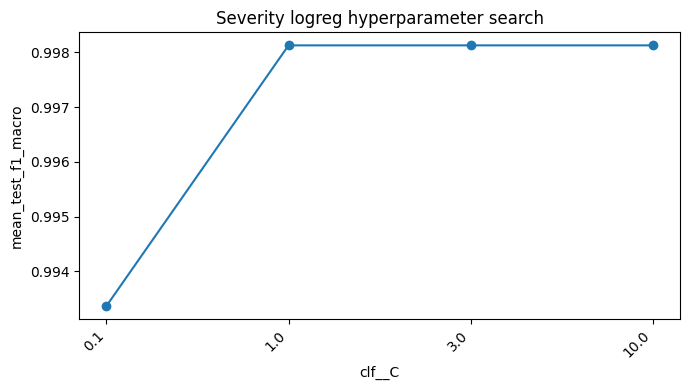

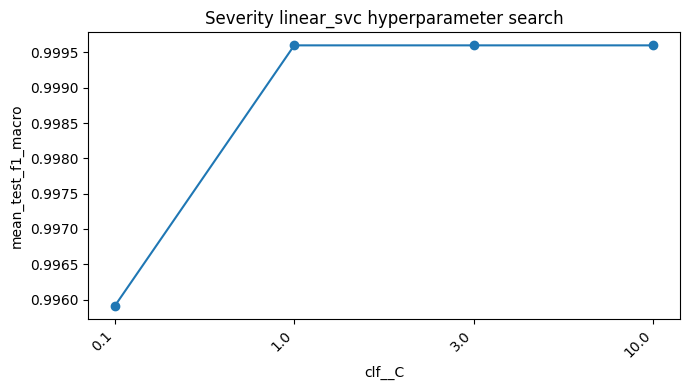

In [41]:
for name, search in severity_searches.items():
    plot_cv_results(search, f'Severity {name} hyperparameter search')


## Attack type modeling

In [42]:
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X,
    y_attack,
    test_size=0.2,
    random_state=SEED,
    stratify=y_attack,
)


In [ ]:
# Attack type: Logistic Regression
attack_logreg_spec = {
    "model": LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear"),
    "params": {"clf__C": [0.1, 1, 3, 10]},
}
attack_logreg = run_search(X_train_a, y_train_a, attack_logreg_spec, sampler=sampler)
evaluate_model(attack_logreg, X_test_a, y_test_a, "attack/logreg")


c:\Users\Kebiyer\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\Kebiyer\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


In [ ]:
# Attack type: Linear SVC
attack_linear_svc_spec = {
    "model": LinearSVC(class_weight="balanced"),
    "params": {"clf__C": [0.1, 1, 3, 10]},
}
attack_linear_svc = run_search(X_train_a, y_train_a, attack_linear_svc_spec, sampler=sampler)
evaluate_model(attack_linear_svc, X_test_a, y_test_a, "attack/linear_svc")


In [ ]:
# Attack type: Random Forest
attack_rf_spec = {
    "model": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced_subsample",
        random_state=SEED,
    ),
    "params": {"clf__max_depth": [None, 10, 20], "clf__min_samples_split": [2, 5]},
    "dense": True,
}
attack_rf = run_search(X_train_a, y_train_a, attack_rf_spec, sampler=sampler)
evaluate_model(attack_rf, X_test_a, y_test_a, "attack/random_forest")


In [ ]:
attack_searches = {
    "logreg": attack_logreg,
    "linear_svc": attack_linear_svc,
    "random_forest": attack_rf,
}

best_attack = max(attack_searches.values(), key=lambda item: item.best_score_)
print("Best attack_type model:", best_attack.best_estimator_)

top3 = top_k_accuracy(best_attack, X_test_a, y_test_a, k=3)
if top3 is not None:
    print("Top-3 accuracy:", top3)


In [ ]:
attack_summary = summarize_searches(attack_searches, "Attack type")
plot_search_summary(attack_summary, "Attack type model comparison (CV best f1_macro)")


In [ ]:
for name, search in attack_searches.items():
    plot_cv_results(search, f'Attack type {name} hyperparameter search')
